# Facial Expression Classification Project

## Project Goal

The objective of this project is to use different models to classify the emotions of the people through facial images. In particular, the models that we are going to use are:


1.   SVM (Support Vector Machine)
2.   CNN from scratch






### Loading the libraries

In [ ]:
from google.colab import drive
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
import random
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import resample
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import matplotlib.cm as cm
import time
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

### Loading the dataset

We upload the dataset, that we previously downloaded from kaggle. We upload the dataset from Drive, because in this way we do not have to upload it from scratch every time that we run the code.

In [ ]:

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/DatasetProjectDM&ML/dataset RAF-DB.zip" -d "/content/RAF-DB"

###  Creating the Dataframe

In the FILE section of Colab we can see that the folder RAF-DB contains 2 CSV files that specifies the labels for train and test set, and the DATASET folder which contains the images for the train and test set.

In [ ]:
TRAIN_DIR = "/content/RAF-DB/DATASET/train"
TEST_DIR = "/content/RAF-DB/DATASET/test"

In [ ]:

train_df = pd.read_csv("/content/RAF-DB/train_labels.csv")
test_df = pd.read_csv("/content/RAF-DB/test_labels.csv")

train_df["path"] = train_df.apply(lambda row: os.path.join(TRAIN_DIR, str(row["label"]), row["image"]), axis=1)
test_df["path"] = test_df.apply(lambda row: os.path.join(TEST_DIR, str(row["label"]), row["image"]), axis=1)

In [ ]:
print(train_df.head())
print(test_df.head())

                     image  label  \
0  train_00001_aligned.jpg      5   
1  train_00002_aligned.jpg      5   
2  train_00003_aligned.jpg      4   
3  train_00004_aligned.jpg      4   
4  train_00005_aligned.jpg      5   

                                                path  
0  /content/RAF-DB/DATASET/train/5/train_00001_al...  
1  /content/RAF-DB/DATASET/train/5/train_00002_al...  
2  /content/RAF-DB/DATASET/train/4/train_00003_al...  
3  /content/RAF-DB/DATASET/train/4/train_00004_al...  
4  /content/RAF-DB/DATASET/train/5/train_00005_al...  
                   image  label  \
0  test_0001_aligned.jpg      5   
1  test_0002_aligned.jpg      1   
2  test_0003_aligned.jpg      4   
3  test_0004_aligned.jpg      1   
4  test_0005_aligned.jpg      5   

                                                path  
0  /content/RAF-DB/DATASET/test/5/test_0001_align...  
1  /content/RAF-DB/DATASET/test/1/test_0002_align...  
2  /content/RAF-DB/DATASET/test/4/test_0003_align...  
3  /content/RAF-

Since we have as labels of the images only numbers from 1 to 7, we can map these numbers to the actual emotion by creating a column in the dataframes.

In [ ]:
label_map = {
    1: "surprise",
    2: "fear",
    3: "disgust",
    4: "happy",
    5: "sad",
    6: "angry",
    7: "neutral"
}

train_df["emotion"] = train_df["label"].map(label_map)
test_df["emotion"] = test_df["label"].map(label_map)

print(train_df.head())
print(test_df.head())

                     image  label  \
0  train_00001_aligned.jpg      5   
1  train_00002_aligned.jpg      5   
2  train_00003_aligned.jpg      4   
3  train_00004_aligned.jpg      4   
4  train_00005_aligned.jpg      5   

                                                path emotion  
0  /content/RAF-DB/DATASET/train/5/train_00001_al...     sad  
1  /content/RAF-DB/DATASET/train/5/train_00002_al...     sad  
2  /content/RAF-DB/DATASET/train/4/train_00003_al...   happy  
3  /content/RAF-DB/DATASET/train/4/train_00004_al...   happy  
4  /content/RAF-DB/DATASET/train/5/train_00005_al...     sad  
                   image  label  \
0  test_0001_aligned.jpg      5   
1  test_0002_aligned.jpg      1   
2  test_0003_aligned.jpg      4   
3  test_0004_aligned.jpg      1   
4  test_0005_aligned.jpg      5   

                                                path   emotion  
0  /content/RAF-DB/DATASET/test/5/test_0001_align...       sad  
1  /content/RAF-DB/DATASET/test/1/test_0002_align...  surp

###  Splitting the train set

In [ ]:

train, val = train_test_split(train_df, test_size=0.2, random_state=42)


In [ ]:
print(f"Train set dimension: {train.shape}")
print(f"Test set dimension: {test_df.shape}")
print(f"Validation set dimension: {val.shape}")

Train set dimension: (9816, 4)
Test set dimension: (3068, 4)
Validation set dimension: (2455, 4)


###  Exploratory Data Analysis

Total number of images:

In [ ]:
print(f"Total train images: {len(train)}")
print(f"Total validation images: {len(val)}")
print(f"Total test images: {len(test_df)}")
print(f"Total images: {len(train) + len(val) + len(test_df)}")


Total train images: 9816
Total validation images: 2455
Total test images: 3068
Total images: 15339


Checking dataset info(missing values & duplicates)

In [ ]:
# Check for missing values
print("Missing values in training set:")
print(train.isnull().sum())

# Check for duplicates
print("\n Duplicated rows in training set:", train.duplicated().sum())

print("Missing values in validation set:")
print(val.isnull().sum())

# Check for duplicates
print("\n Duplicated rows in validation set:", val.duplicated().sum())

# Same for test set
print("\n Missing values in test set:")
print(test_df.isnull().sum())
print("Duplicated rows in test set:", test_df.duplicated().sum())


Missing values in training set:
image      0
label      0
path       0
emotion    0
dtype: int64

 Duplicated rows in training set: 0
Missing values in validation set:
image      0
label      0
path       0
emotion    0
dtype: int64

 Duplicated rows in validation set: 0

 Missing values in test set:
image      0
label      0
path       0
emotion    0
dtype: int64
Duplicated rows in test set: 0


Image dimensions:

In [ ]:


print("Image dimensions (width x height):")
for path in train['path']:
    with Image.open(path) as img:
        print(f"{os.path.basename(path)}: {img.size}")




Output streaming troncato alle ultime 5000 righe.
train_06010_aligned.jpg: (100, 100)
train_02053_aligned.jpg: (100, 100)
train_08540_aligned.jpg: (100, 100)
train_04669_aligned.jpg: (100, 100)
train_04299_aligned.jpg: (100, 100)
train_06647_aligned.jpg: (100, 100)
train_03784_aligned.jpg: (100, 100)
train_01009_aligned.jpg: (100, 100)
train_11197_aligned.jpg: (100, 100)
train_02186_aligned.jpg: (100, 100)
train_03624_aligned.jpg: (100, 100)
train_12008_aligned.jpg: (100, 100)
train_07440_aligned.jpg: (100, 100)
train_11873_aligned.jpg: (100, 100)
train_08686_aligned.jpg: (100, 100)
train_08284_aligned.jpg: (100, 100)
train_04835_aligned.jpg: (100, 100)
train_04060_aligned.jpg: (100, 100)
train_04757_aligned.jpg: (100, 100)
train_11308_aligned.jpg: (100, 100)
train_00091_aligned.jpg: (100, 100)
train_01988_aligned.jpg: (100, 100)
train_00471_aligned.jpg: (100, 100)
train_01327_aligned.jpg: (100, 100)
train_07280_aligned.jpg: (100, 100)
train_08325_aligned.jpg: (100, 100)
train_09858_al

Image Formats:

In [ ]:
formats = []

for path in train_df["path"].sample(200, random_state=42):
    with Image.open(path) as img:
        formats.append(img.format)

format_counts = pd.Series(formats).value_counts()
print("Image formats:")
print(format_counts)


Image formats:
JPEG    200
Name: count, dtype: int64


Distribution of the train set

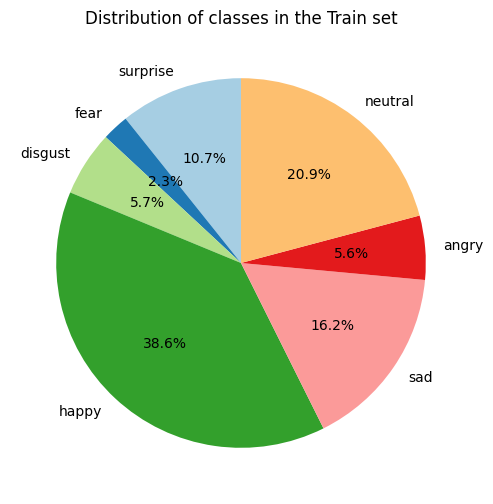

In [ ]:


# Order of emotions (from your label_map)
emotion_order = ["surprise", "fear", "disgust", "happy", "sad", "angry", "neutral"]

# Count and reorder
train_counts = train["emotion"].value_counts().reindex(emotion_order)

# Pie chart — Train
plt.figure(figsize=(6, 6))
plt.pie(
    train_counts.values,
    labels=train_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Paired.colors
)
plt.title("Distribution of classes in the Train set")
plt.show()


Distribution of the validation set

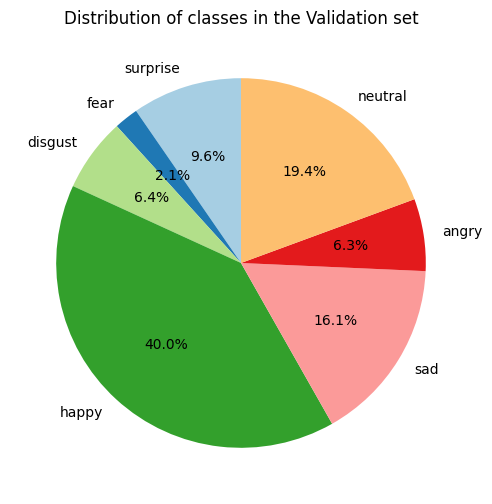

In [ ]:
# Count and reorder
val_counts = val["emotion"].value_counts().reindex(emotion_order)

# Pie chart — Validation
plt.figure(figsize=(6, 6))
plt.pie(
    val_counts.values,
    labels=val_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Paired.colors
)
plt.title("Distribution of classes in the Validation set")
plt.show()


Distribution of the test set

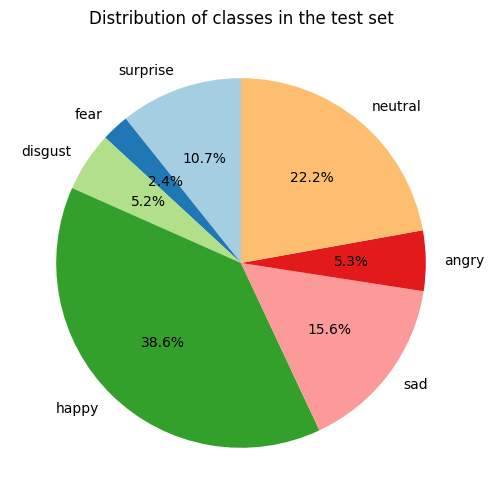

In [ ]:
# Count and reorder
test_counts = test_df["emotion"].value_counts().reindex(emotion_order)

# Pie chart — Validation
plt.figure(figsize=(6, 6))
plt.pie(
    test_counts.values,
    labels=test_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Paired.colors
)
plt.title("Distribution of classes in the test set")
plt.show()

Let's check some images to see the kind of images we are dealing with

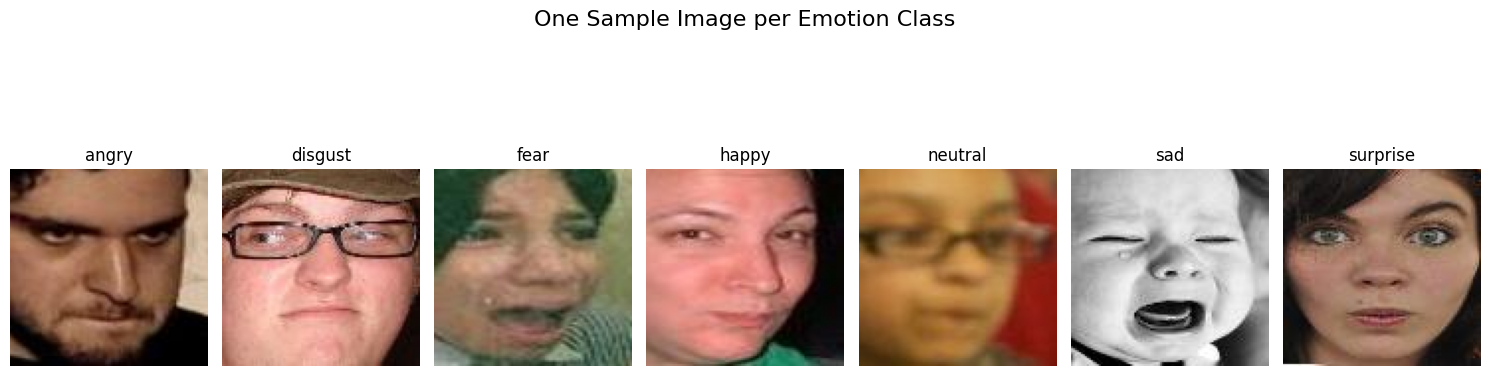

In [ ]:


# Get the list of emotions (classes)
emotions = sorted(train_df["emotion"].unique())

# Create a figure
plt.figure(figsize=(15, 5))

for i, emotion in enumerate(emotions):
    # Select one random image from that emotion
    sample_row = train_df[train_df["emotion"] == emotion].sample(1, random_state=random.randint(0, 10000)).iloc[0]
    img_path = sample_row["path"]

    # Open and display the image
    with Image.open(img_path) as img:
        plt.subplot(1, len(emotions), i + 1)
        plt.imshow(img)
        plt.title(emotion)
        plt.axis("off")

plt.suptitle("One Sample Image per Emotion Class", fontsize=16)
plt.tight_layout()
plt.show()


Since some of the models that we are going to use need different preprocess, we will do a preprocessing phase for each model separately.

# Convolutional Neural Network

### Preprocessing

In [ ]:
# Let's create a copy of the train, val and test sets
train_cnn = train.copy()
val_cnn = val.copy()
test_cnn = test_df.copy()

# Parameters
IMG_SIZE = (100, 100)
BATCH_SIZE = 32

# Analyze the distribution of the different classes
class_counts = train_cnn["emotion"].value_counts()
max_count = class_counts.max()

print("Number of images per class (train):")
print(class_counts)
print(f"\nMost occured class → {max_count} images")

# Balance the train set by resampling the minorities classes
balanced_train = pd.DataFrame()

for emotion, count in class_counts.items():
    subset = train_cnn[train_cnn["emotion"] == emotion]
    if count < max_count:
        # oversampling with substitution
        subset_up = resample(
            subset,
            replace=True,
            n_samples=max_count,
            random_state=42
        )
        balanced_train = pd.concat([balanced_train, subset_up])
    else:
        balanced_train = pd.concat([balanced_train, subset])

balanced_train = balanced_train.sample(frac=1, random_state=42).reset_index(drop=True)
print("\n Balanced train set:")
print(balanced_train["emotion"].value_counts())

# Definition of the DataGenerator

# Data augmentation only for train set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Normalization of val and test sets
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators from Dataframe
train_generator = train_datagen.flow_from_dataframe(
    dataframe=balanced_train,
    x_col="path",
    y_col="emotion",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_cnn,
    x_col="path",
    y_col="emotion",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_cnn,
    x_col="path",
    y_col="emotion",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Final control
print("\nTraining images:", train_generator.samples)
print("Validation images:", val_generator.samples)
print("Test images:", test_generator.samples)
print("Classes:", train_generator.class_indices)


Number of images per class (train):
emotion
happy       3789
neutral     2048
sad         1587
surprise    1054
disgust      559
angry        550
fear         229
Name: count, dtype: int64

Most occured class → 3789 images

 Balanced train set:
emotion
surprise    3789
angry       3789
neutral     3789
sad         3789
disgust     3789
fear        3789
happy       3789
Name: count, dtype: int64
Found 26523 validated image filenames belonging to 7 classes.
Found 2455 validated image filenames belonging to 7 classes.
Found 3068 validated image filenames belonging to 7 classes.

Training images: 26523
Validation images: 2455
Test images: 3068
Classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


### CNN Architecture

In [ ]:


#Let's define the architecture of our CNN
model = Sequential([
    Conv2D(32, (3,3), input_shape = (100,100,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    Dense(7, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 98, 98, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 21, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 2,493,639 (9.51 MB)

 Trainable params: 2,491,655 (9.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:


# We set steps_per_epoch to 156. Assuming a batch size of 32, this processes
# approximately 5000 samples per epoch (156 * 32), which acts as a sample
# of the total training data for faster iteration.
STEPS_PER_EPOCH_SAMPLE = 829

# Let's train the model on the train generator, using as validation data the validation generator
history = model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH_SAMPLE, # ADDED: Subsamples data for faster epochs
    epochs=50,
    validation_data=val_generator,
    callbacks=[
        EarlyStopping(monitor = 'val_loss',patience=10, restore_best_weights=True), #stop the training when the validation loss does not improve for 10 epoches in a row
        ReduceLROnPlateau(monitor = 'val_loss',factor=0.2, patience=2,min_lr = 0.00001) #decrease the learning rate when the validation loss does not improve for 2 epoches in a row.
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
829/829 ━━━━━━━━━━━━━━━━━━━━ 114s 123ms/step - accuracy: 0.2414 - loss: 2.0428 - val_accuracy: 0.3804 - val_loss: 1.7158 - learning_rate: 5.0000e-04
Epoch 2/50
829/829 ━━━━━━━━━━━━━━━━━━━━ 90s 108ms/step - accuracy: 0.3508 - loss: 1.7152 - val_accuracy: 0.4798 - val_loss: 1.4052 - learning_rate: 5.0000e-04
Epoch 3/50
829/829 ━━━━━━━━━━━━━━━━━━━━ 88s 106ms/step - accuracy: 0.4361 - loss: 1.5080 - val_accuracy: 0.5316 - val_loss: 1.2685 - learning_rate: 5.0000e-04
Epoch 4/50
829/829 ━━━━━━━━━━━━━━━━━━━━ 87s 105ms/step - accuracy: 0.5079 - loss: 1.3237 - val_accuracy: 0.6798 - val_loss: 0.9134 - learning_rate: 5.0000e-04
Epoch 5/50
829/829 ━━━━━━━━━━━━━━━━━━━━ 115s 138ms/step - accuracy: 0.5501 - loss: 1.2064 - val_accuracy: 0.6379 - val_loss: 1.0052 - learning_rate: 5.0000e-04
Epoch 6/50
829/829 ━━━━━━━━━━━━━━━━━━━━ 90s 108ms/step - accuracy: 0.5852 - loss: 1.1149 - val_accuracy: 0.6538 - val_loss: 0.9448 - learning_rate: 5.0000e-04
Epoch 7/50
829/829 ━━━━━━━━━━━━━━━━━━━━ 93s 

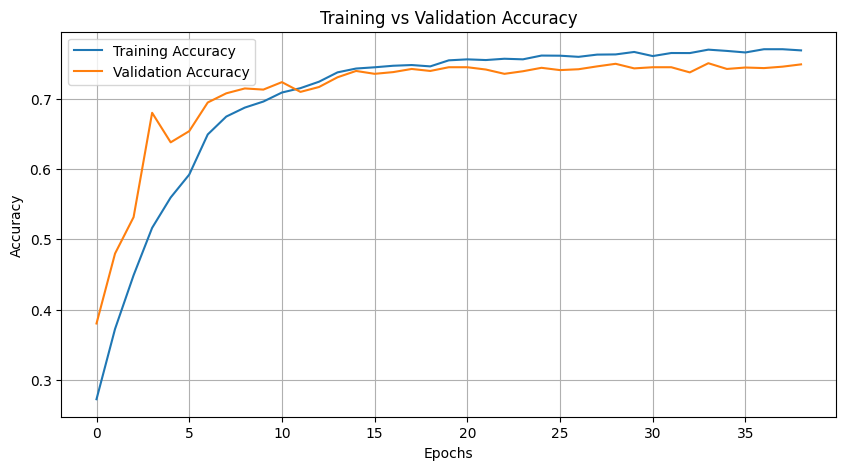

In [ ]:


# Plot Train accuracy vs Validation accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(10,5))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


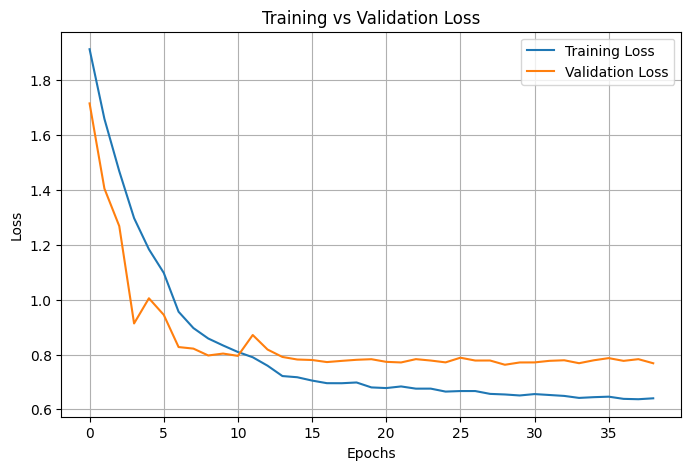

In [ ]:
# Plot Train loss vs Validation loss
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8,5))
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Found 3068 validated image filenames belonging to 7 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


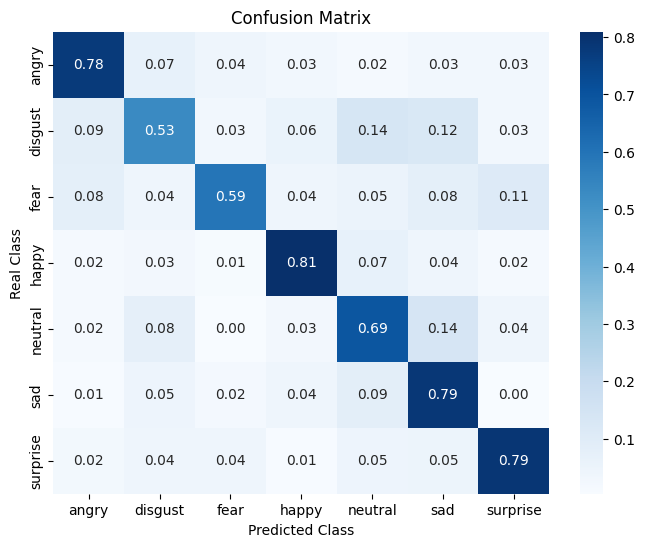


Classification Report:

              precision    recall  f1-score   support

       angry       0.66      0.78      0.71       162
     disgust       0.38      0.53      0.45       160
        fear       0.44      0.59      0.51        74
       happy       0.94      0.81      0.87      1185
     neutral       0.74      0.69      0.71       680
         sad       0.66      0.79      0.72       478
    surprise       0.79      0.79      0.79       329

    accuracy                           0.76      3068
   macro avg       0.66      0.71      0.68      3068
weighted avg       0.78      0.76      0.76      3068

96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.7845 - loss: 0.6655
Test Loss: 0.7169
Test Accuracy: 0.7562


In [ ]:


# Re-define test_generator for CNN with correct IMG_SIZE
CNN_IMG_SIZE = (100, 100)
# Ensure test_cnn and BATCH_SIZE are available from previous cells
test_datagen_cnn = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen_cnn.flow_from_dataframe(
    dataframe=test_cnn,
    x_col="path",
    y_col="emotion",
    target_size=CNN_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Predict on the test set
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)  # class with highest probability
y_true = test_generator.classes     # real classes
class_labels = list(test_generator.class_indices.keys())  # classes names

# Compute the normalized confusion matrix
cm_cnn= confusion_matrix(y_true, y_pred, normalize = 'true')

# Plot the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm_cnn, annot = True ,fmt=".2f",  cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.ylabel("Real Class")
plt.xlabel("Predicted Class")
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Evaluation on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


### Saliency Map

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Saliency Map:
True Class: sad
Predicted Class: sad (Confidence: 0.87)


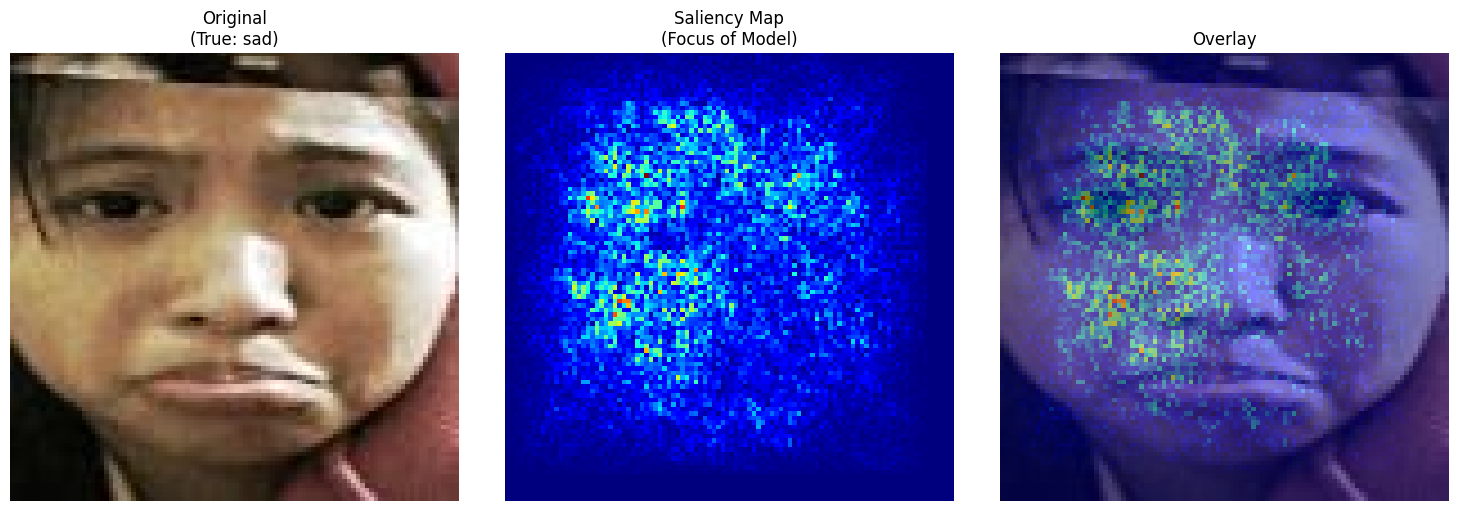

In [ ]:


def make_saliency_map(model, img_array, class_idx):

    # Convert the image in a tensor
    img_tensor = tf.convert_to_tensor(img_array)

    if len(img_tensor.shape) == 3:
        img_tensor = tf.expand_dims(img_tensor, axis=0)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)

        # Forward pass
        preds = model(img_tensor)

        target_score = preds[:, class_idx]

    grads = tape.gradient(target_score, img_tensor)

    saliency = tf.reduce_max(tf.abs(grads), axis=-1)

    return saliency.numpy().squeeze()

def plot_saliency(model, generator):

    # 1. we take a batch of images from the test generator
    imgs, labels = next(iter(generator))

    # First image of the batch
    img = imgs[0]

    # Let's find the predicted class from the model
    img_batch = np.expand_dims(img, axis=0)
    preds = model.predict(img_batch)
    pred_idx = np.argmax(preds[0])

    # Let's take the names of the classes
    idx_to_label = {v: k for k, v in generator.class_indices.items()}
    pred_label = idx_to_label[pred_idx]
    real_label = idx_to_label[np.argmax(labels[0])]

    print(f"Saliency Map:")
    print(f"True Class: {real_label}")
    print(f"Predicted Class: {pred_label} (Confidence: {preds[0][pred_idx]:.2f})")

    # 2. Compute the map
    saliency_map = make_saliency_map(model, img, pred_idx)

    # 3. Visualization
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # A: Original Image
    ax[0].imshow(img)
    ax[0].set_title(f"Original\n(True: {real_label})")
    ax[0].axis('off')

    # B: Saliency Map (Heatmap)
    saliency_norm = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min() + 1e-8)
    ax[1].imshow(saliency_norm, cmap='jet')
    ax[1].set_title(f"Saliency Map\n(Focus of Model)")
    ax[1].axis('off')

    # C: Overlay
    ax[2].imshow(img)
    ax[2].imshow(saliency_norm, cmap='jet', alpha=0.5)
    ax[2].set_title("Overlay")
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()


plot_saliency(model, test_generator)

## SVM Model

Data Preparation and Generator Creation

In [ ]:


IMG_SIZE = (48, 48)
BATCH_SIZE = 32

#Creating Copied DataFrames
train_svm = train.copy()
val_svm = val.copy()
test_svm = test_df.copy()

#Rebalancing the Training Set (to balance the generators)
class_counts = train_svm["emotion"].value_counts()
max_count = class_counts.max()
balanced_train_svm = pd.DataFrame()
for emotion, count in class_counts.items():
    subset = train_svm[train_svm["emotion"] == emotion]
    if count < max_count:
        subset_up = resample(subset, replace=True, n_samples=max_count, random_state=42)
        balanced_train_svm = pd.concat([balanced_train_svm, subset_up])
    else:
        balanced_train_svm = pd.concat([balanced_train_svm, subset])
balanced_train_svm = balanced_train_svm.sample(frac=1, random_state=42).reset_index(drop=True)

#Defining and Creating Data Generators
datagen = ImageDataGenerator(rescale=1./255) # Normalization only

train_generator = datagen.flow_from_dataframe(
    dataframe=balanced_train_svm, x_col="path", y_col="emotion",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False, verbose=0
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_svm, x_col="path", y_col="emotion",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False, verbose=0
)

test_generator = datagen.flow_from_dataframe(
    dataframe=test_svm, x_col="path", y_col="emotion",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False, verbose=0
)
print("Data generators created")

Found 26523 validated image filenames belonging to 7 classes.
Found 2455 validated image filenames belonging to 7 classes.
Found 3068 validated image filenames belonging to 7 classes.
Data generators created


Custom Feature Extraction for All Sets

In [ ]:


#Custom Preprocessing Function
def preprocess_for_svm(generator):
    X = []
    y = []
    generator.reset()
    gen = generator.__iter__()

    print(f"Starting feature extraction for {generator.samples} images...")
    for _ in tqdm(range(len(generator))):
        batch_imgs, batch_labels = next(gen)
        batch_flat = batch_imgs.reshape(batch_imgs.shape[0], -1)
        X.extend(batch_flat)
        y.extend(np.argmax(batch_labels, axis=1))

    return np.array(X), np.array(y)

#Execute Feature Extraction for all three sets
print("Running feature extraction for training data:")
X_train, y_train = preprocess_for_svm(train_generator)

print("Running feature extraction for validation data")
X_val, y_val = preprocess_for_svm(val_generator)

print("Running feature extraction for test data:")
X_test, y_test = preprocess_for_svm(test_generator)

print(f"\nTraining features shape: {X_train.shape}")

Running feature extraction for training data:
Starting feature extraction for 26523 images...


  0%|          | 0/829 [00:00<?, ?it/s]

Running feature extraction for validation data
Starting feature extraction for 2455 images...


  0%|          | 0/77 [00:00<?, ?it/s]

Running feature extraction for test data:
Starting feature extraction for 3068 images...


  0%|          | 0/96 [00:00<?, ?it/s]


Training features shape: (26523, 6912)


PCA Pipeline

In [ ]:


#PCA Pipeline Setup
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=100, random_state=42))
])

print("Fitting PCA on Training Data...")
start_time = time.time()
pca_pipeline.fit(X_train) # Fit only on training data
end_time = time.time()
print(f"PCA fitting complete in {end_time - start_time:.2f} seconds.")

#Transforming all datasets
X_train_pca = pca_pipeline.transform(X_train)
X_val_pca = pca_pipeline.transform(X_val)
X_test_pca = pca_pipeline.transform(X_test)

print(f"\nReduced feature count: {X_train_pca.shape[1]}")

Fitting PCA on Training Data...
PCA fitting complete in 24.31 seconds.

Reduced feature count: 100


## Linear Kernel SVM

In [ ]:


#We Optimized Linear SVM Model Training (on PCA features)
svm_linear_pca = LinearSVC(C=1, random_state=42, verbose=1, max_iter=10000)

print("\n Starting FAST LinearSVC Training...")
start_time = time.time()
svm_linear_pca.fit(X_train_pca, y_train)
end_time = time.time()
print(f"LinearSVC Training Complete in {end_time - start_time:.2f} seconds. ")

#Prediction and Val
y_val_pred_linear = svm_linear_pca.predict(X_val_pca)
y_pred_linear = svm_linear_pca.predict(X_test_pca)

print(f"Validation Accuracy (LinearSVC + PCA): {accuracy_score(y_val, y_val_pred_linear):.4f}")


 Starting FAST LinearSVC Training...
[LibLinear]LinearSVC Training Complete in 14.89 seconds. (Much faster now!)
Validation Accuracy (LinearSVC + PCA): 0.5613


Final Linear SVM Evaluation

Accuracy (LinearSVC + PCA): 0.5752933507170795

Classification Report (LinearSVC + PCA):

              precision    recall  f1-score   support

       angry       0.34      0.63      0.44       162
     disgust       0.21      0.39      0.27       160
        fear       0.18      0.51      0.26        74
       happy       0.84      0.72      0.77      1185
     neutral       0.66      0.45      0.54       680
         sad       0.49      0.38      0.43       478
    surprise       0.56      0.67      0.61       329

    accuracy                           0.58      3068
   macro avg       0.47      0.54      0.48      3068
weighted avg       0.64      0.58      0.59      3068



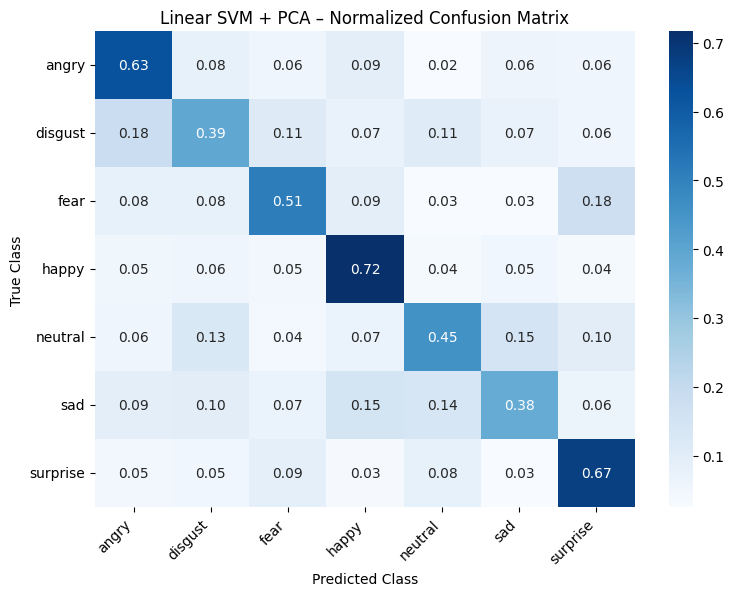

In [ ]:


#Final Evaluation on Test Set
class_labels = sorted(test_svm['emotion'].unique())

print("Accuracy (LinearSVC + PCA):", accuracy_score(y_test, y_pred_linear))
print("\nClassification Report (LinearSVC + PCA):\n")
print(classification_report(y_test, y_pred_linear, target_names=class_labels))

# Confusion Matrix Plot
# we first Calculated the normalaized Confusion Matrix
cm_linear = confusion_matrix(y_test, y_pred_linear, normalize='true')

#format
plt.figure(figsize=(9, 7))
sns.heatmap(cm_linear, annot=True, fmt=".2f", cmap="Blues", # Use '.2f' for percentages/floats
            xticklabels=class_labels, yticklabels=class_labels)

plt.title("Linear SVM + PCA – Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

#y-axis labels are centered and visible
plt.yticks(rotation=0)

#x-axis labels are rotated and aligned
plt.xticks(rotation=45, ha='right')

#Manually adjust the bottom margin to prevent cut-off labels
plt.subplots_adjust(bottom=0.20, left=0.15)

plt.show()

## RBF Kernel SVM


 Starting RBF SVM Training...
RBF SVM Training Complete in 70.80 seconds.
Validation Accuracy (RBF SVM + PCA): 0.6248
Test Accuracy (RBF SVM + PCA): 0.6300521512385919


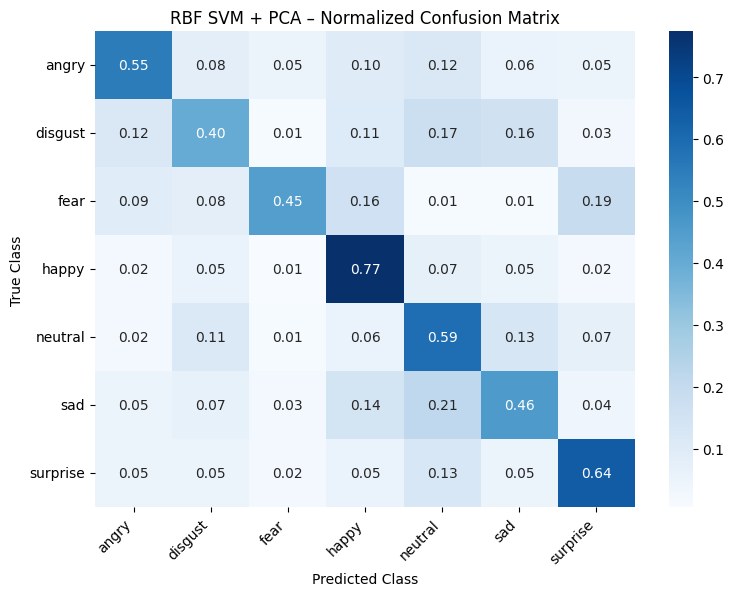

In [ ]:
from sklearn.svm import SVC


# --- RBF SVM Model Training (on PCA features) ---
# NOTE: Using the standard SVC solver for RBF kernel.
svm_rbf_pca = SVC(kernel="rbf", C=1, random_state=42, verbose=False)

print("\n Starting RBF SVM Training...")
start_time = time.time()
svm_rbf_pca.fit(X_train_pca, y_train)
end_time = time.time()
print(f"RBF SVM Training Complete in {end_time - start_time:.2f} seconds.")
# --- Prediction and Evaluation ---
y_val_pred_rbf = svm_rbf_pca.predict(X_val_pca)
y_pred_rbf = svm_rbf_pca.predict(X_test_pca)

print(f"Validation Accuracy (RBF SVM + PCA): {accuracy_score(y_val, y_val_pred_rbf):.4f}")
print("Test Accuracy (RBF SVM + PCA):", accuracy_score(y_test, y_pred_rbf))

# Confusion Matrix Plot (Normalized for recall)
class_labels = sorted(test_svm['emotion'].unique())
cm_rbf = confusion_matrix(y_test, y_pred_rbf, normalize='true')

plt.figure(figsize=(9, 7))
sns.heatmap(cm_rbf, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)

plt.title("RBF SVM + PCA – Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.20, left=0.15)
plt.show()

## Fuzzy score Membership

applying the Fuzzy score membership to the RBF Kernel SVM:
Calculate Predictions and Find Sample

In [ ]:
#Assuming svm_rbf_pca, X_test_pca, and y_test are defined
y_pred_rbf = svm_rbf_pca.predict(X_test_pca)

#Identification of the misclassified Sample
misclassified_mask = (y_test != y_pred_rbf)
misclassified_indices = np.where(misclassified_mask)[0]

if len(misclassified_indices) == 0:
    print("No misclassified samples found by RBF SVM. Cannot proceed.")
    random_index = -1
else:
    random_index = np.random.choice(misclassified_indices)
    X_sample_pca = X_test_pca[random_index].reshape(1, -1)

    print(f"Misclassified Sample Identified")
    print(f"Sample index {random_index} selected for visualization.")

Misclassified Sample Identified
Sample index 2804 selected for visualization.


/tmp/ipython-input-3204302634.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classifier_labels, y=distances, palette='vlag', ax=ax2)


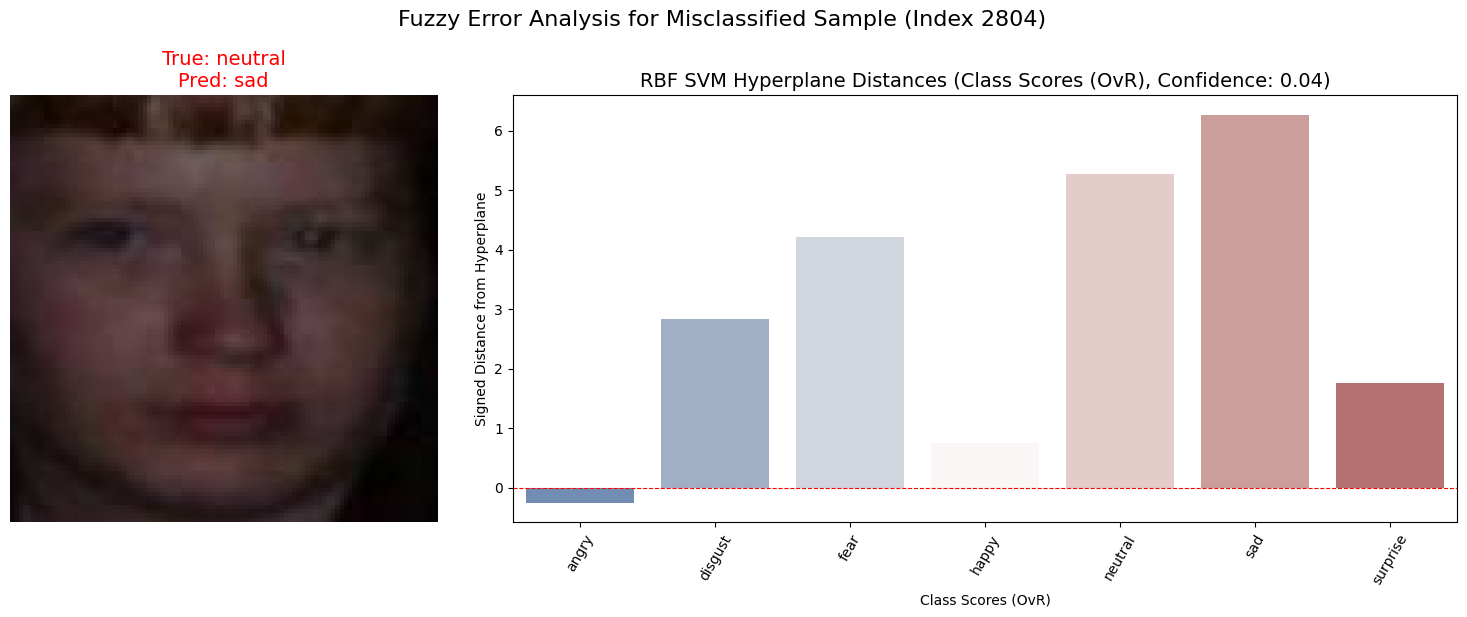

In [ ]:




if 'random_index' not in locals() or random_index == -1:
    print("Cannot plot: run the preceding analysis to identify a misclassified sample first")
else:
    #getting image path and distances (Input data)
    distances_matrix = svm_rbf_pca.decision_function(X_sample_pca)
    distances = distances_matrix.flatten()

    # Calculate metrics for plot title
    single_min_abs_distance = np.min(np.abs(distances))
    max_abs_dist_sample = np.max(np.abs(distances))
    fuzzy_score_relative = single_min_abs_distance / max_abs_dist_sample

    #we generated Labels Based on Distance Array Length
    emotion_names = sorted(test_svm['emotion'].unique())
    N_DISTANCES = len(distances)

    if N_DISTANCES == len(emotion_names):
        classifier_labels = emotion_names
        label_type = "Class Scores (OvR)"
    elif N_DISTANCES == len(emotion_names) * (len(emotion_names) - 1) // 2:
        classifier_labels = []
        for i in range(len(emotion_names)):
            for j in range(i + 1, len(emotion_names)):
                classifier_labels.append(f"{emotion_names[i]} vs {emotion_names[j]}")
        label_type = "Binary Classifiers (OvO)"
    else:
        raise ValueError(f"Mismatched data dimensions: Model output has {N_DISTANCES} distances. Expected 7 or 21.")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 2]})

    # AXIS 1: IMAGE DISPLAY
    try:
        sample_path = test_svm.iloc[random_index]['path']
        img = Image.open(sample_path)
        ax1.imshow(img)

        # Get labels using the variables defined in the preceding cell
        label_map = {0: "angry", 1: "disgust", 2: "fear", 3: "happy", 4: "neutral", 5: "sad", 6: "surprise"}
        true_name = label_map.get(y_test[random_index], 'Unknown')
        pred_name = label_map.get(svm_rbf_pca.predict(X_sample_pca)[0], 'Unknown')

        ax1.set_title(f"True: {true_name}\nPred: {pred_name}", fontsize=14, color='red')
        ax1.axis('off')
    except Exception as e:
        ax1.set_title(f"Image not found/loaded: {e}", color='gray')
        ax1.axis('off')

    # AXIS 2 :BAR CHART DISPLAY
    sns.barplot(x=classifier_labels, y=distances, palette='vlag', ax=ax2)
    plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Decision Boundary (0)')

    ax2.set_title(f"RBF SVM Hyperplane Distances ({label_type}, Confidence: {fuzzy_score_relative:.2f})", fontsize=14)
    ax2.set_ylabel("Signed Distance from Hyperplane")
    ax2.set_xlabel(label_type)

    ax2.tick_params(axis='x', rotation=60)
    fig.suptitle(f"Fuzzy Error Analysis for Misclassified Sample (Index {random_index})", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

## Polynomial Kernel SVM

In [ ]:


# Subsampling Fix for Speed (TRAINING DATA ONLY)
# Reduce N from ~14,000 to 5,000 samples for fast training of the Polynomial kernel.
N_SAMPLES_QUICK_TEST = 5000
if X_train_pca.shape[0] > N_SAMPLES_QUICK_TEST:
    # Subsample X_train_pca while ensuring stratification (balanced classes)
    X_train_sub, _, y_train_sub, _ = train_test_split(
        X_train_pca, y_train,
        test_size=1 - (N_SAMPLES_QUICK_TEST / X_train_pca.shape[0]),
        random_state=42,
        stratify=y_train
    )
    print(f"Warning: Training on subsampled data ({X_train_sub.shape[0]} samples) for speed.")
else:
    X_train_sub = X_train_pca
    y_train_sub = y_train

#Polynomial SVM Model Training (on Subsampled PCA features)
svm_poly_pca = SVC(kernel="poly", degree=3, C=1, random_state=42, verbose=False)

print("\nStarting Polynomial SVM Training...")
start_time = time.time()
#Fit on the subsampled data: X_train_sub
svm_poly_pca.fit(X_train_sub, y_train_sub)
end_time = time.time()
print(f"Polynomial SVM Training Complete in {end_time - start_time:.2f} seconds.")

# --- Prediction and Validation ---
y_val_pred_poly = svm_poly_pca.predict(X_val_pca)
y_pred_poly = svm_poly_pca.predict(X_test_pca)

print(f"Validation Accuracy (Polynomial SVM + PCA): {accuracy_score(y_val, y_val_pred_poly):.4f}")


Starting Polynomial SVM Training...
Polynomial SVM Training Complete in 2.31 seconds.
Validation Accuracy (Polynomial SVM + PCA): 0.5352


Accuracy (Polynomial SVM + PCA): 0.5241199478487614

Classification Report (Polynomial SVM + PCA):

              precision    recall  f1-score   support

       angry       0.34      0.30      0.32       162
     disgust       0.13      0.38      0.19       160
        fear       0.55      0.35      0.43        74
       happy       0.73      0.76      0.75      1185
     neutral       0.51      0.39      0.44       680
         sad       0.39      0.37      0.38       478
    surprise       0.61      0.39      0.48       329

    accuracy                           0.52      3068
   macro avg       0.47      0.42      0.43      3068
weighted avg       0.56      0.52      0.53      3068



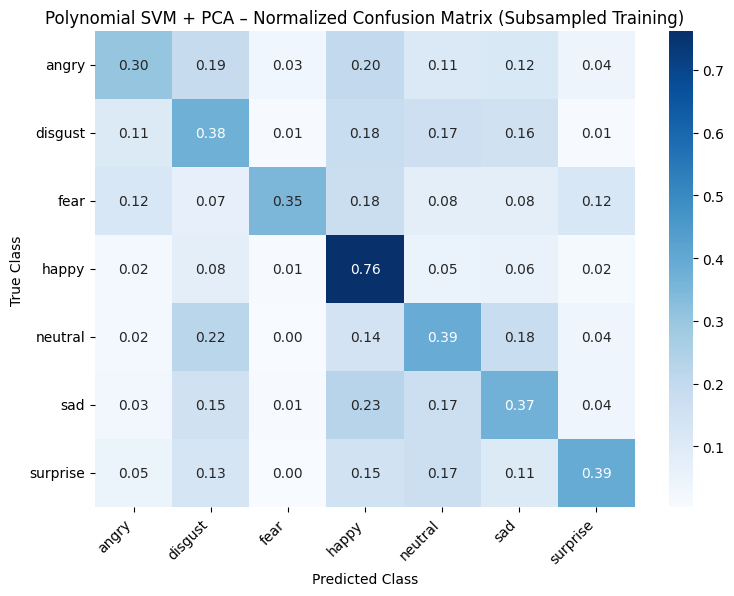

In [ ]:
#Evaluation on Test Set
class_labels = sorted(test_svm['emotion'].unique())

print("Accuracy (Polynomial SVM + PCA):", accuracy_score(y_test, y_pred_poly))
print("\nClassification Report (Polynomial SVM + PCA):\n")
print(classification_report(y_test, y_pred_poly, target_names=class_labels))

# Confusion Matrix Plot (Normalized)
cm_poly = confusion_matrix(y_test, y_pred_poly, normalize='true')

plt.figure(figsize=(9, 7))
sns.heatmap(cm_poly, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)

plt.title("Polynomial SVM + PCA – Normalized Confusion Matrix (Subsampled Training)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.20, left=0.15)

plt.show()

## ROC Curve

/tmp/ipython-input-4201134483.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Spectral', n_classes)


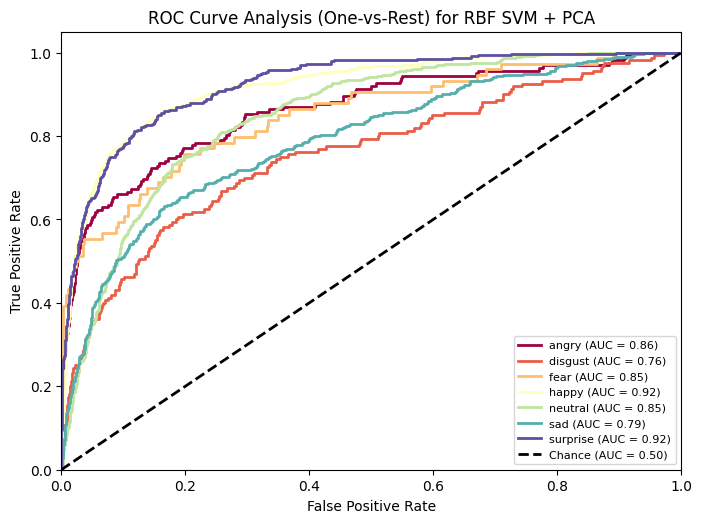

In [ ]:


# --- Binarize the labels (One-vs-Rest) ---
# We use the integer labels (0-6)
y_test_bin = label_binarize(y_test, classes=np.arange(7))
n_classes = y_test_bin.shape[1]

#Getting Score Estimates (decision_function)
# lets assume svm_rbf_pca and X_test_pca are defined
y_score = svm_rbf_pca.decision_function(X_test_pca)

# we calculated the ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
label_map_list = sorted(test_svm['emotion'].unique())

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap('Spectral', n_classes)

for i in range(n_classes):
    emotion_name = label_map_list[i]

    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f'{emotion_name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Analysis (One-vs-Rest) for RBF SVM + PCA')
plt.legend(loc="lower right", fontsize=8)
plt.subplots_adjust(bottom=0.15)
plt.show()

## Comparison of the different SVM models

Comparison Plot: Linear vs RBF vs Polynomial Kernels

/tmp/ipython-input-1632214535.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kernels, y=accuracies, palette='viridis')


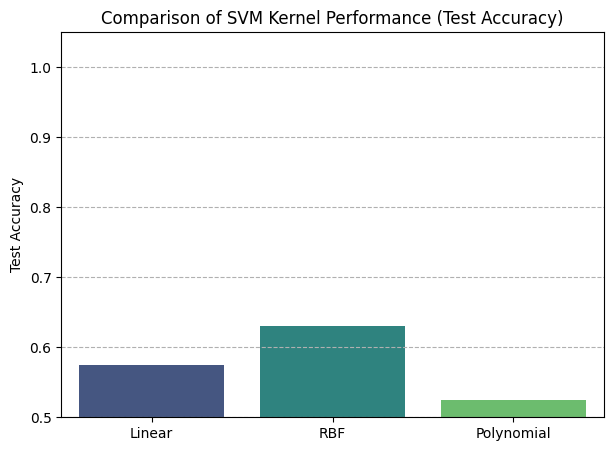

In [ ]:


#Getting the validation accuracies calculated
acc_linear = accuracy_score(y_test, y_pred_linear)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
acc_poly = accuracy_score(y_test, y_pred_poly)


kernels = ['Linear', 'RBF', 'Polynomial']
accuracies = [acc_linear, acc_rbf, acc_poly]

plt.figure(figsize=(7, 5))
sns.barplot(x=kernels, y=accuracies, palette='viridis')

plt.title('Comparison of SVM Kernel Performance (Test Accuracy)')
plt.ylabel('Test Accuracy')
plt.ylim(np.floor(min(accuracies) * 10) / 10, 1.05)
plt.grid(axis='y', linestyle='--')
plt.show()

## Model comparision: CNN VS SVM

/tmp/ipython-input-2778621357.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test Accuracy', data=comparison_data, palette='coolwarm')


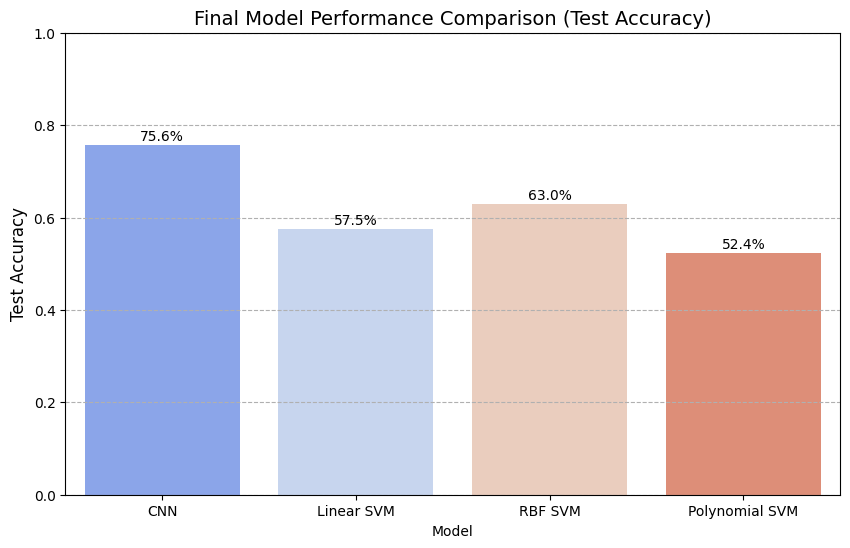

In [ ]:


#Get Linear SVM Test Accuracy
# Retrain LinearSVC for accurate comparison
svm_linear_pca = LinearSVC(C=1, random_state=42, verbose=0, max_iter=10000)
svm_linear_pca.fit(X_train_pca, y_train)
y_pred_linear = svm_linear_pca.predict(X_test_pca)
acc_linear = accuracy_score(y_test, y_pred_linear)

#Get RBF SVM Test Accuracy
acc_rbf = accuracy_score(y_test, y_pred_rbf)

# Get Polynomial SVM Test Accuracy
# Use the subsampling fix for speed
N_SAMPLES_QUICK_TEST = 5000
X_train_sub, _, y_train_sub, _ = train_test_split(X_train_pca, y_train, test_size=1 - (N_SAMPLES_QUICK_TEST / X_train_pca.shape[0]), random_state=42, stratify=y_train)

svm_poly_pca = SVC(kernel="poly", degree=3, C=1, random_state=42, verbose=False)
svm_poly_pca.fit(X_train_sub, y_train_sub)
y_pred_poly = svm_poly_pca.predict(X_test_pca)
acc_poly = accuracy_score(y_test, y_pred_poly)

#Get CNN Accuracy
CNN_ACCURACY = test_accuracy

comparison_data = pd.DataFrame({
    'Model': ['CNN', 'Linear SVM', 'RBF SVM', 'Polynomial SVM'],
    'Test Accuracy': [CNN_ACCURACY, acc_linear, acc_rbf, acc_poly]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Test Accuracy', data=comparison_data, palette='coolwarm')

plt.title('Final Model Performance Comparison (Test Accuracy)', fontsize=14)
plt.ylabel('Test Accuracy', fontsize=12)
plt.ylim(0.0, 1.0)

# Add exact percentage accuracy values on top of bars
for index, row in comparison_data.iterrows():
    plt.text(index, row['Test Accuracy'] + 0.01, f'{row["Test Accuracy"]*100:.1f}%',
             color='black', ha="center")

plt.grid(axis='y', linestyle='--')
plt.show()